# Three-Modality Fusion: Metric+Log ML Score $\times$ VLM Visual Score

This notebook implements the natural continuation of the VLM integration work
(`07_vlm_dashboard_analysis.ipynb`): fusing the **visual** anomaly verdict from the
dual-engine VLM module with the **tabular ML** anomaly probability (metric + log
features, the Random Forest detector from Section 6.1 of the paper, F1 = 98.45%) to
produce a single decision that genuinely exploits all three modalities — the literal
claim of the paper's future-work item #1 ("*achieving full three-modality
exploitation*").

**Method.** For a sample $x$ with dashboard image $I$:

$$
P_{\text{final}}(x, I) = \alpha \cdot P_{\text{ML}}(x) + (1-\alpha)\cdot
c_{\text{VLM}}(I)\cdot \mathbb{1}[s_{\text{VLM}}(I)=\text{ANOMALY}], \qquad \alpha \in [0,1]
$$

where $P_{\text{ML}}(x)$ is the Random Forest's anomaly probability and
$(s_{\text{VLM}}, c_{\text{VLM}})$ are the VLM's visual status and confidence
(`models/vlm_engine.py`). We sweep $\alpha$ on a held-out set and compare the fused
decision's $F_1$ against the ML-only ($\alpha=1$) and VLM-only ($\alpha=0$) baselines.

**Data-leakage safeguard.** The samples used for the VLM calls are drawn *exclusively*
from the trained model's **test split** (never seen during Random Forest training), so
$P_{\text{ML}}(x)$ is a genuine held-out prediction, not a training-set score.

| Step | Topic |
|------|------|
| 1 | Train the metric+log ML baseline (Random Forest) |
| 2 | Select a VLM evaluation subset strictly from the test split |
| 3 | Compute the leak-free ML score $P_{\text{ML}}(x)$ |
| 4 | Compute the VLM visual score (Gemini Vision + Ollama LLaVA) |
| 5 | Score-level fusion and $\alpha$ sweep |
| 6 | Results table and plot |
| 7 | Qualitative check: samples the fusion corrects |
| 8 | Save results and discuss limitations |


## 1 — Environment Setup

Same requirements as `07_vlm_dashboard_analysis.ipynb`, plus the modeling stack already
used by `models/train.py`:
```
pip install scikit-learn xgboost google-generativeai python-dotenv pillow requests
```
`GEMINI_API_KEY` must be set in `.env`; `ollama pull llava:7b` is optional (the local
engine step is skipped automatically if unavailable).


In [1]:
import sys, os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import yaml
import requests
from pathlib import Path
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

warnings.filterwarnings('ignore')
sys.path.insert(0, r"d:\multimodal-rca-engine")

from dotenv import load_dotenv
load_dotenv(Path(r"d:\multimodal-rca-engine\.env"))

from models.data_loader import MultimodalDataLoader
from models.rca_models import AnomalyDetector
from models.vlm_engine import VLMEngine

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

PROJECT_DIR = Path(r"d:\multimodal-rca-engine")
DATASET_DIR = PROJECT_DIR / "data" / "multimodal_dataset"
RESULTS_DIR = PROJECT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Libraries loaded.")


Libraries loaded.


## 2 — Train the Metric+Log ML Baseline (Random Forest)

We reproduce the paper's primary anomaly detector: a Random Forest over the fused
metric-statistics + log-feature + TF-IDF feature space (`models/rca_models.py::
AnomalyDetector`), trained on a 70/10/20 stratified split — identical configuration to
`models/train.py`. This gives us the **leak-free** $P_{\text{ML}}(x)$ we will fuse with
the visual score.


In [2]:
loader = MultimodalDataLoader(dataset_dir=DATASET_DIR, noise_level=0.15, feature_dropout=0.05, seed=42)
loader.load_metadata()
data = loader.build_feature_matrix(max_samples=10000, include_tfidf=True)
splits = loader.split_data(data, test_size=0.2, val_size=0.1, random_state=42)

anomaly_detector = AnomalyDetector(model_type="random_forest")
anomaly_detector.train(splits["train"], splits["val"])

baseline_test = anomaly_detector.evaluate(splits["test"], "Test")
print(f"\nBaseline (metric+log only) test F1: {baseline_test['f1']:.4f}  "
      f"(paper reports 0.9845 on the full pipeline)")


 Loaded metadata: 10,000 samples
   Normal:  5,000
   Anomaly: 5,000

 Building feature matrix for 10,000 samples...


   Processed 2,000/10,000 samples...


   Processed 4,000/10,000 samples...


   Processed 6,000/10,000 samples...


   Processed 8,000/10,000 samples...


...

    Applying noise (level=0.15, dropout=0.05)...
    Building TF-IDF matrix...


      TF-IDF shape: (10000, 100)
    y_root_cause: 6 classes → [np.str_('config'), np.str_('hardware'), np.str_('network'), np.str_('none'), np.str_('resource'), np.str_('software')]
    y_severity: 4 classes → [np.str_('critical'), np.str_('high'), np.str_('medium'), np.str_('none')]
    y_layer: 11 classes → [np.str_('application'), np.str_('cdn'), np.str_('database'), np.str_('firewall'), np.str_('kubernetes_deployments'), np.str_('kubernetes_ingress'), np.str_('linux_host'), np.str_('linux_vm'), np.str_('network'), np.str_('proxy'), np.str_('storage')]
    y_scenario: 23 classes → [np.str_('APP_001'), np.str_('APP_002'), np.str_('CDN_001'), np.str_('CDN_002'), np.str_('DB_001'), np.str_('DB_002'), np.str_('FW_001'), np.str_('FW_002'), np.str_('HOST_001'), np.str_('HOST_002'), np.str_('K8D_001'), np.str_('K8D_002'), np.str_('K8I_001'), np.str_('K8I_002'), np.str_('NET_001'), np.str_('NET_002'), np.str_('PRX_001'), np.str_('PRX_002'), np.str_('STR_001'), np.str_('STR_002'), np.str_('

  Features: 213 | Samples: 7,000
  Labels: [3500 3500]


  Training time: 2.8s

   Validation Results — Anomaly Detection (random_forest):
  ─────────────────────────────────────────────
  Accuracy             0.9840
  Precision            0.9764
  Recall               0.9920
  F1 Score             0.9841
  AUC-ROC              0.9992
  ─────────────────────────────────────────────
  Confusion Matrix:
             Pred Normal  Pred Anomaly
  Actual N        488           12
  Actual A          4          496



   Test Results — Anomaly Detection (random_forest):
  ─────────────────────────────────────────────
  Accuracy             0.9860
  Precision            0.9850
  Recall               0.9870
  F1 Score             0.9860
  AUC-ROC              0.9988
  ─────────────────────────────────────────────
  Confusion Matrix:
             Pred Normal  Pred Anomaly
  Actual N        985           15
  Actual A         13          987

Baseline (metric+log only) test F1: 0.9860  (paper reports 0.9845 on the full pipeline)


## 3 — Select a VLM Evaluation Subset Strictly from the Test Split

To keep $P_{\text{ML}}(x)$ leak-free, the samples sent to the VLM engines must come from
`splits["test"]` — the Random Forest never saw these during training. We apply the same
stratified strategy as the previous notebook (diverse layers for normals, one sample per
distinct visual anomaly pattern), restricted to the test-split sample IDs.


In [3]:
with open(PROJECT_DIR / "configs" / "anomaly_scenarios.yaml", "r", encoding="utf-8") as f:
    catalog_cfg = yaml.safe_load(f)
scenario_catalog = {}
for layer_key, layer_data in catalog_cfg["layers"].items():
    for sc in layer_data["scenarios"]:
        scenario_catalog[sc["id"]] = sc

metadata = pd.read_csv(DATASET_DIR / "metadata.csv")
test_ids = set(splits["test"]["sample_ids"])
test_metadata = metadata[metadata["sample_id"].isin(test_ids)].copy()
print(f"Test split: {len(test_metadata):,} samples "
      f"({(test_metadata['is_anomaly']==0).sum()} normal / {(test_metadata['is_anomaly']==1).sum()} anomaly)")

rng = np.random.RandomState(7)

# 4 normal samples from 4 different layers, drawn only from the test split
normal_pool = test_metadata[test_metadata["is_anomaly"] == 0]
normal_layers = rng.choice(normal_pool["layer"].unique(), size=min(4, normal_pool["layer"].nunique()), replace=False)
normal_picks = pd.concat(
    [normal_pool[normal_pool["layer"] == lyr].sample(1, random_state=7) for lyr in normal_layers]
)

# One anomalous sample per distinct visual anomaly_type, from the test split
anomaly_pool = test_metadata[test_metadata["is_anomaly"] == 1].copy()
anomaly_pool["anomaly_type"] = anomaly_pool["scenario_id"].map(
    lambda sid: scenario_catalog.get(sid, {}).get("anomaly_type", "unknown")
)
anomaly_picks = (
    anomaly_pool.groupby("anomaly_type", group_keys=False)
    .apply(lambda g: g.sample(1, random_state=7))
)

eval_samples = pd.concat([normal_picks, anomaly_picks]).reset_index(drop=True)
eval_samples["anomaly_type"] = eval_samples["scenario_id"].map(
    lambda sid: scenario_catalog.get(sid, {}).get("anomaly_type", "-") if pd.notna(sid) else "-"
)

print(f"\nSelected {len(eval_samples)} test-split samples for VLM evaluation "
      f"({(eval_samples['is_anomaly']==0).sum()} normal / {(eval_samples['is_anomaly']==1).sum()} anomaly):")
eval_samples[["sample_id", "layer_name", "is_anomaly", "scenario_name", "anomaly_type", "severity"]]


Test split: 2,000 samples (1000 normal / 1000 anomaly)

Selected 9 test-split samples for VLM evaluation (4 normal / 5 anomaly):


,sample_id,layer_name,is_anomaly,scenario_name,anomaly_type,severity
0,sample_003963,Network,0,NaN,-,NaN
1,sample_002361,Application Layer,0,NaN,-,NaN
2,sample_000302,CDN,0,NaN,-,NaN
3,sample_000992,Proxy,0,NaN,-,NaN
4,sample_006313,Proxy,1,Response Latency,gradual_rise,medium
5,sample_006653,Kubernetes Ingress,1,Unbalanced Traffic Distribution,oscillation,medium
6,sample_006527,Kubernetes Ingress,1,High Error Rate,spike,high
7,sample_009873,Linux Host (Physical Machine),1,Disk Error Count Increase,step_increase,critical
8,sample_007227,Kubernetes Deployments,1,CPU Usage Increase,sustained_high,high


## 4 — Preview the Selected Dashboards


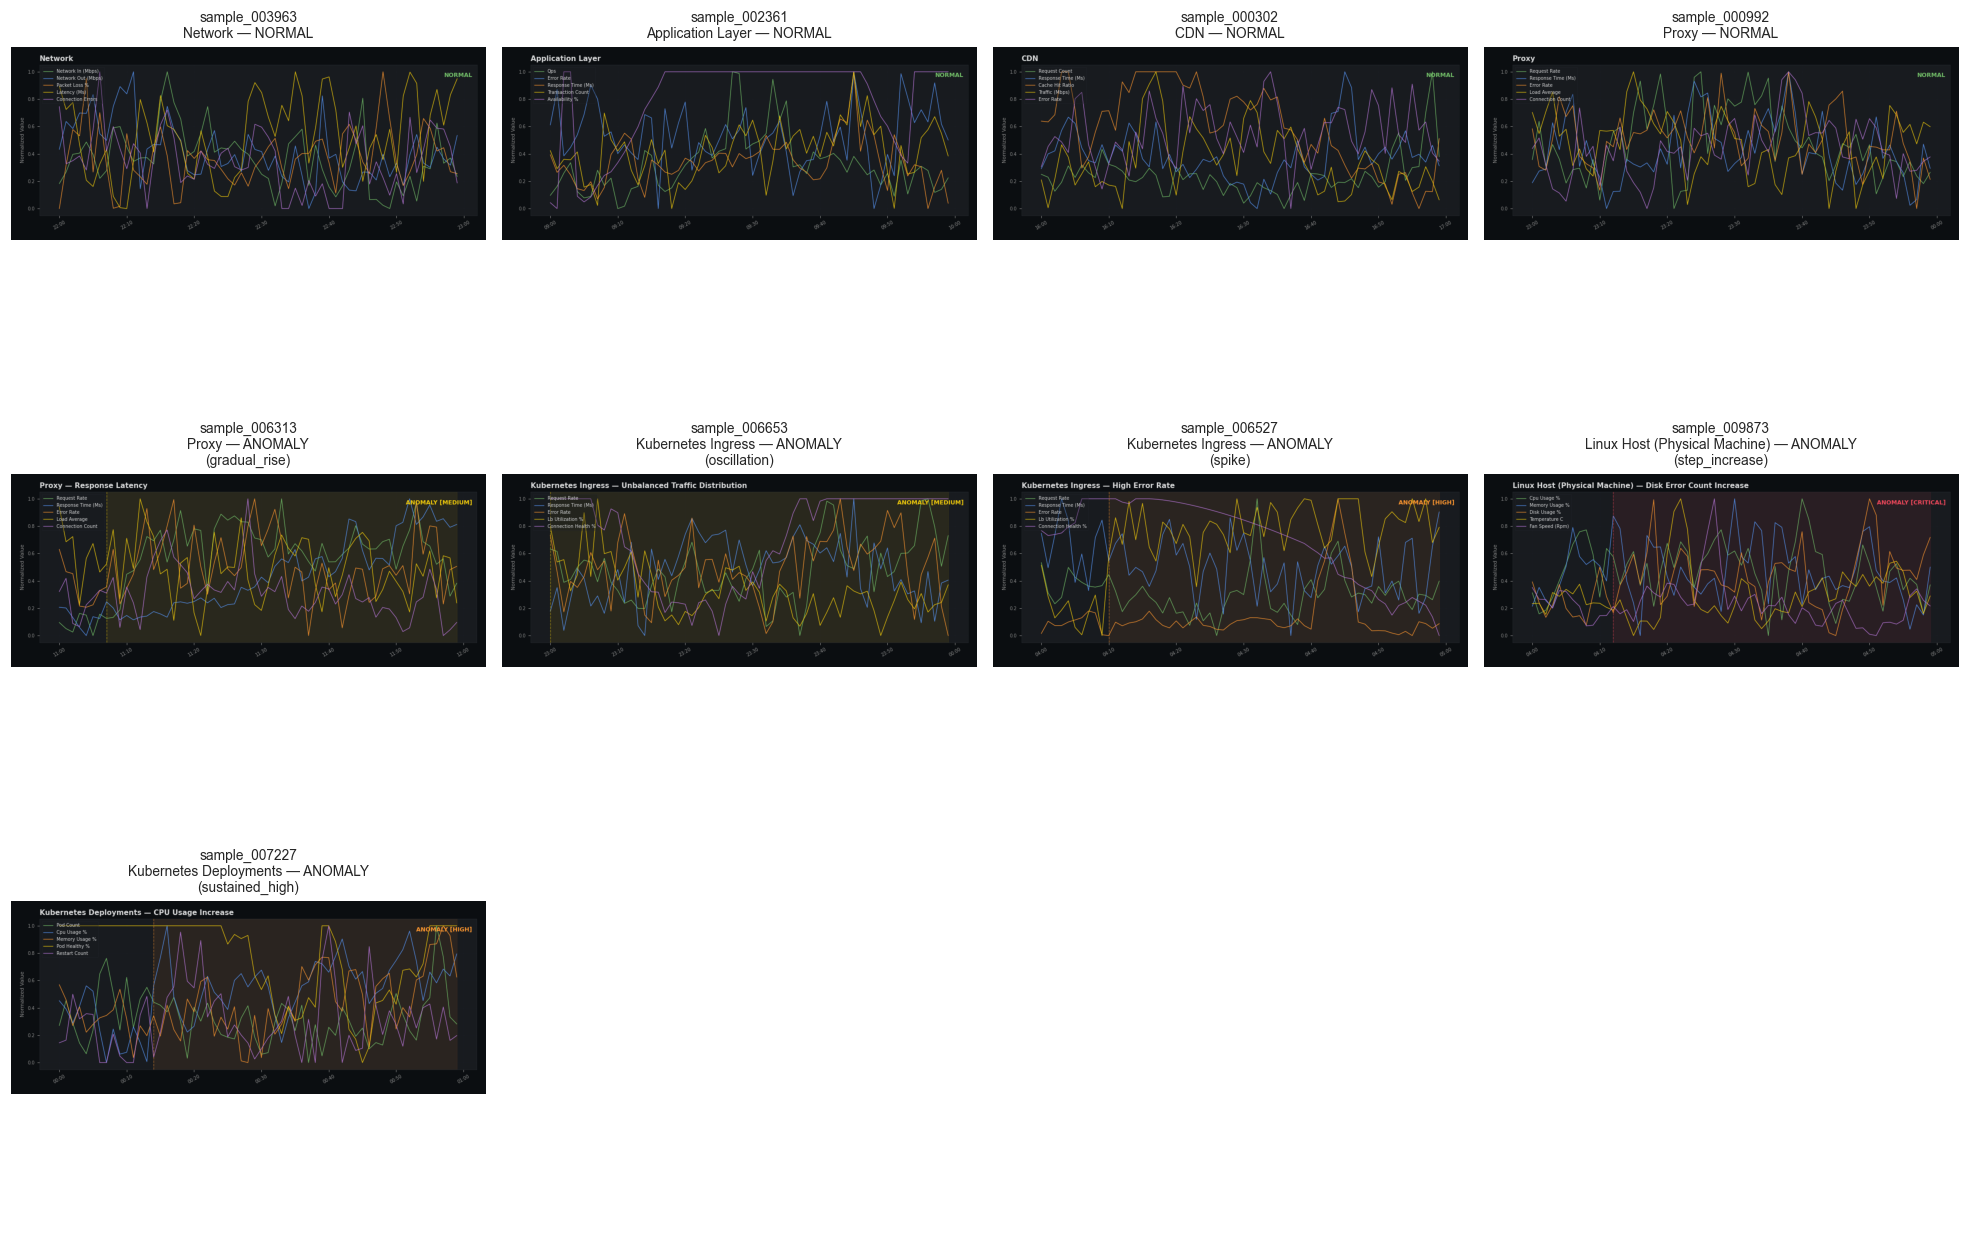

In [4]:
n = len(eval_samples)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4.2 * nrows))
axes = np.atleast_2d(axes)

for i, row in eval_samples.iterrows():
    ax = axes[i // ncols][i % ncols]
    img_path = DATASET_DIR / row["dashboard_path"]
    ax.imshow(mpimg.imread(img_path))
    status = "ANOMALY" if row["is_anomaly"] else "NORMAL"
    label = f"{row['sample_id']}\n{row['layer_name']} — {status}"
    if row["is_anomaly"]:
        label += f"\n({row['anomaly_type']})"
    ax.set_title(label, fontsize=9)
    ax.axis("off")

for j in range(n, nrows * ncols):
    axes[j // ncols][j % ncols].axis("off")

plt.tight_layout()
plt.show()


## 5 — Compute the Leak-Free ML Score $P_{\text{ML}}(x)$

We slice the already-trained model's **test split** down to just the rows matching our
selected `sample_id`s (preserving feature/label alignment) and call
`AnomalyDetector.predict_proba`, so every $P_{\text{ML}}(x)$ below is a genuine
out-of-sample prediction.


In [5]:
def build_mini_split(full_split, wanted_ids):
    # Slice a data split down to the rows matching `wanted_ids`, preserving order.
    id_to_pos = {sid: i for i, sid in enumerate(full_split["sample_ids"])}
    positions = [id_to_pos[sid] for sid in wanted_ids]
    mini = {
        "X_metrics": full_split["X_metrics"].iloc[positions].reset_index(drop=True),
        "X_logs": full_split["X_logs"].iloc[positions].reset_index(drop=True),
        "y_anomaly": full_split["y_anomaly"][positions],
        "sample_ids": [full_split["sample_ids"][p] for p in positions],
    }
    if full_split.get("X_tfidf") is not None:
        mini["X_tfidf"] = full_split["X_tfidf"][positions]
    return mini

wanted_ids = eval_samples["sample_id"].tolist()
mini_split = build_mini_split(splits["test"], wanted_ids)
p_ml = anomaly_detector.predict_proba(mini_split)

eval_samples["P_ML"] = p_ml
eval_samples[["sample_id", "is_anomaly", "P_ML"]]


,sample_id,is_anomaly,P_ML
0,sample_003963,0,0.005013
1,sample_002361,0,0.002509
2,sample_000302,0,0.016677
3,sample_000992,0,0.000028
4,sample_006313,1,0.832286
5,sample_006653,1,0.965833
6,sample_006527,1,0.975833
7,sample_009873,1,0.997333
8,sample_007227,1,0.975786


## 6 — Compute the VLM Visual Score

Gemini Vision runs on all selected samples; Ollama LLaVA runs on a smaller, stratified
subset (2 normal + 2 anomaly) for the same runtime reasons as the previous notebook.


In [6]:
gemini_engine = VLMEngine(backend="gemini")

OLLAMA_BASE_URL = os.environ.get("OLLAMA_BASE_URL", "http://localhost:11434")
OLLAMA_VISION_MODEL = os.environ.get("DEFAULT_OLLAMA_VISION_MODEL", "llava:7b")
OLLAMA_AVAILABLE = False
try:
    tags = requests.get(f"{OLLAMA_BASE_URL}/api/tags", timeout=5).json()
    installed = [m["name"] for m in tags.get("models", [])]
    OLLAMA_AVAILABLE = OLLAMA_VISION_MODEL in installed
except requests.exceptions.RequestException:
    pass
ollama_engine = VLMEngine(backend="ollama") if OLLAMA_AVAILABLE else None
print(f"Gemini ready. Ollama/{OLLAMA_VISION_MODEL} available: {OLLAMA_AVAILABLE}")


 Initializing VLMEngine (Backend: GEMINI)


 Initializing VLMEngine (Backend: OLLAMA)
Gemini ready. Ollama/llava:7b available: True


In [7]:
gemini_results = []
print(f"Running Gemini Vision on {len(eval_samples)} test-split dashboards...\n")

for i, row in eval_samples.iterrows():
    img_path = DATASET_DIR / row["dashboard_path"]
    res = gemini_engine.analyze_dashboard(img_path)
    gt_status = "ANOMALY" if row["is_anomaly"] else "NORMAL"
    ok = "error" not in res
    c_vlm = float(res.get("visual_confidence", 0.0)) if ok else 0.0
    s_vlm = res.get("visual_status", "UNKNOWN") if ok else "UNKNOWN"

    gemini_results.append({
        "sample_id": row["sample_id"], "gt_status": gt_status,
        "visual_status": s_vlm, "visual_confidence": c_vlm,
        "visual_pattern": res.get("visual_pattern"),
        "latency_seconds": res.get("latency_seconds"), "parsed_ok": ok,
    })
    match = "MATCH" if s_vlm == gt_status else "MISS "
    print(f"[{i+1}/{len(eval_samples)}] {row['sample_id']:<16} gt={gt_status:<7} "
          f"pred={s_vlm:<7} {match} c={c_vlm:.2f}")

gemini_df = pd.DataFrame(gemini_results)
eval_samples = eval_samples.merge(gemini_df, on="sample_id", how="left")
eval_samples[["sample_id", "is_anomaly", "P_ML", "visual_status", "visual_confidence"]]


Running Gemini Vision on 9 test-split dashboards...



[1/9] sample_003963    gt=NORMAL  pred=NORMAL  MATCH c=0.98


[2/9] sample_002361    gt=NORMAL  pred=NORMAL  MATCH c=0.95


[3/9] sample_000302    gt=NORMAL  pred=NORMAL  MATCH c=0.98


[4/9] sample_000992    gt=NORMAL  pred=NORMAL  MATCH c=0.98


...

[6/9] sample_006653    gt=ANOMALY pred=ANOMALY MATCH c=1.00


[7/9] sample_006527    gt=ANOMALY pred=ANOMALY MATCH c=1.00


[8/9] sample_009873    gt=ANOMALY pred=ANOMALY MATCH c=1.00


[9/9] sample_007227    gt=ANOMALY pred=ANOMALY MATCH c=1.00


,sample_id,is_anomaly,P_ML,visual_status,visual_confidence
0,sample_003963,0,0.005013,NORMAL,0.98
1,sample_002361,0,0.002509,NORMAL,0.95
2,sample_000302,0,0.016677,NORMAL,0.98
3,sample_000992,0,0.000028,NORMAL,0.98
4,sample_006313,1,0.832286,ANOMALY,0.95
5,sample_006653,1,0.965833,ANOMALY,1.00
6,sample_006527,1,0.975833,ANOMALY,1.00
7,sample_009873,1,0.997333,ANOMALY,1.00
8,sample_007227,1,0.975786,ANOMALY,1.00


In [8]:
ollama_results = []
if OLLAMA_AVAILABLE:
    subset = pd.concat([
        eval_samples[eval_samples["is_anomaly"] == 0].head(2),
        eval_samples[eval_samples["is_anomaly"] == 1].head(2),
    ]).reset_index(drop=True)
    print(f"Running Ollama LLaVA on {len(subset)} dashboards (2 normal + 2 anomaly)...\n")
    for i, row in subset.iterrows():
        img_path = DATASET_DIR / row["dashboard_path"]
        res = ollama_engine.analyze_dashboard(img_path)
        gt_status = "ANOMALY" if row["is_anomaly"] else "NORMAL"
        ok = "error" not in res
        s_vlm = res.get("visual_status", "UNKNOWN") if ok else "UNKNOWN"
        ollama_results.append({
            "sample_id": row["sample_id"], "gt_status": gt_status,
            "visual_status": s_vlm, "visual_confidence": res.get("visual_confidence"),
            "latency_seconds": res.get("latency_seconds"), "parsed_ok": ok,
        })
        match = "MATCH" if s_vlm == gt_status else "MISS "
        print(f"[{i+1}/{len(subset)}] {row['sample_id']:<16} gt={gt_status:<7} pred={s_vlm:<7} {match}")
else:
    print("Ollama / llava:7b not available — skipping the local-engine comparison.")

ollama_df = pd.DataFrame(ollama_results)
ollama_df


Running Ollama LLaVA on 4 dashboards (2 normal + 2 anomaly)...



[1/4] sample_003963    gt=NORMAL  pred=ANOMALY MISS 


[2/4] sample_002361    gt=NORMAL  pred=ANOMALY MISS 


[3/4] sample_006313    gt=ANOMALY pred=ANOMALY MATCH


[4/4] sample_006653    gt=ANOMALY pred=ANOMALY MATCH


,sample_id,gt_status,visual_status,visual_confidence,latency_seconds,parsed_ok
0,sample_003963,NORMAL,ANOMALY,0.8,141.859,True
1,sample_002361,NORMAL,ANOMALY,0.8,104.539,True
2,sample_006313,ANOMALY,ANOMALY,0.8,97.573,True
3,sample_006653,ANOMALY,ANOMALY,0.9,86.777,True


## 7 — Score-Level Fusion and $\alpha$ Sweep

We combine $P_{\text{ML}}(x)$ (Section 5) with the Gemini visual score (Section 6, run on
every selected sample, unlike the smaller Ollama subset) via

$$
P_{\text{final}} = \alpha \cdot P_{\text{ML}} + (1-\alpha)\cdot c_{\text{VLM}}\cdot
\mathbb{1}[s_{\text{VLM}}=\text{ANOMALY}]
$$

thresholded at $0.5$ to obtain a binary decision, and sweep $\alpha \in \{0, 0.05,
\dots, 1.0\}$. $\alpha=1$ reduces to the ML-only baseline; $\alpha=0$ reduces to the
VLM-only baseline.


In [9]:
y_true = eval_samples["is_anomaly"].values
p_ml_arr = eval_samples["P_ML"].values
c_vlm_arr = eval_samples["visual_confidence"].fillna(0.0).values
is_anomaly_pred_vlm = (eval_samples["visual_status"] == "ANOMALY").astype(float).values
vlm_score = c_vlm_arr * is_anomaly_pred_vlm

alphas = np.round(np.arange(0.0, 1.05, 0.05), 2)
sweep = []
for alpha in alphas:
    p_final = alpha * p_ml_arr + (1 - alpha) * vlm_score
    y_pred = (p_final >= 0.5).astype(int)
    sweep.append({
        "alpha": alpha,
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
    })
sweep_df = pd.DataFrame(sweep)

ml_only = sweep_df[sweep_df["alpha"] == 1.0].iloc[0]
vlm_only = sweep_df[sweep_df["alpha"] == 0.0].iloc[0]
best = sweep_df.loc[sweep_df["f1"].idxmax()]

print(f"ML-only   (alpha=1.00): F1={ml_only['f1']:.3f}  Acc={ml_only['accuracy']:.3f}")
print(f"VLM-only  (alpha=0.00): F1={vlm_only['f1']:.3f}  Acc={vlm_only['accuracy']:.3f}")
print(f"Best fusion (alpha={best['alpha']:.2f}): F1={best['f1']:.3f}  Acc={best['accuracy']:.3f}")
sweep_df


ML-only   (alpha=1.00): F1=1.000  Acc=1.000
VLM-only  (alpha=0.00): F1=1.000  Acc=1.000
Best fusion (alpha=0.00): F1=1.000  Acc=1.000


,alpha,f1,precision,recall,accuracy
0,0.00,1.0,1.0,1.0,1.0
1,0.05,1.0,1.0,1.0,1.0
2,0.10,1.0,1.0,1.0,1.0
3,0.15,1.0,1.0,1.0,1.0
4,0.20,1.0,1.0,1.0,1.0
5,0.25,1.0,1.0,1.0,1.0
6,0.30,1.0,1.0,1.0,1.0
7,0.35,1.0,1.0,1.0,1.0
8,0.40,1.0,1.0,1.0,1.0
9,0.45,1.0,1.0,1.0,1.0


## 8 — Results: $F_1$ vs. $\alpha$


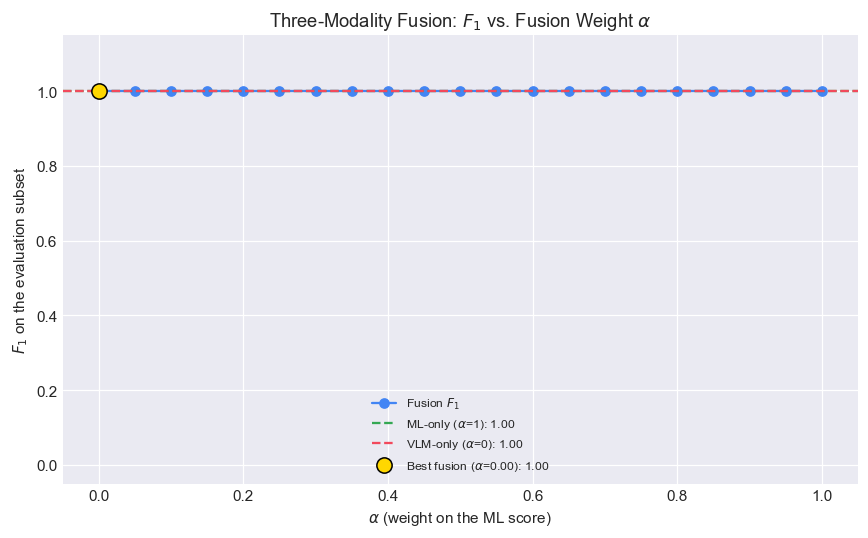

Figure saved to d:\multimodal-rca-engine\results\figures\trimodal_fusion_alpha_sweep.png


In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sweep_df["alpha"], sweep_df["f1"], marker="o", color="#4285F4", label="Fusion $F_1$")
ax.axhline(ml_only["f1"], color="#34a853", linestyle="--", label=f"ML-only ($\\alpha$=1): {ml_only['f1']:.2f}")
ax.axhline(vlm_only["f1"], color="#f2495c", linestyle="--", label=f"VLM-only ($\\alpha$=0): {vlm_only['f1']:.2f}")
ax.scatter([best["alpha"]], [best["f1"]], color="gold", edgecolor="black", zorder=5, s=100,
           label=f"Best fusion ($\\alpha$={best['alpha']:.2f}): {best['f1']:.2f}")
ax.set_xlabel(r"$\alpha$ (weight on the ML score)")
ax.set_ylabel(r"$F_1$ on the evaluation subset")
ax.set_title("Three-Modality Fusion: $F_1$ vs. Fusion Weight $\\alpha$")
ax.set_ylim(-0.05, 1.15)
ax.legend(loc="lower center", fontsize=8)
plt.tight_layout()

fig_path = RESULTS_DIR / "figures" / "trimodal_fusion_alpha_sweep.png"
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Figure saved to {fig_path}")


## 9 — Qualitative Check: Samples the Fusion Corrects

We look for any sample where the ML-only decision (threshold $0.5$ on $P_{\text{ML}}$) or
the VLM-only decision was wrong, but the best-$\alpha$ fusion decision is correct.


In [11]:
alpha_star = best["alpha"]
eval_samples["pred_ml_only"] = (p_ml_arr >= 0.5).astype(int)
eval_samples["pred_vlm_only"] = is_anomaly_pred_vlm.astype(int)
eval_samples["p_final"] = alpha_star * p_ml_arr + (1 - alpha_star) * vlm_score
eval_samples["pred_fusion"] = (eval_samples["p_final"] >= 0.5).astype(int)

corrected = eval_samples[
    (eval_samples["pred_fusion"] == eval_samples["is_anomaly"]) &
    ((eval_samples["pred_ml_only"] != eval_samples["is_anomaly"]) |
     (eval_samples["pred_vlm_only"] != eval_samples["is_anomaly"]))
]

if len(corrected) == 0:
    print("No sample in this small evaluation subset was mis-classified by either "
          "single-modality baseline, so the fusion has nothing to correct here — "
          "a larger benchmark is needed to observe this effect empirically.")
else:
    print(f"{len(corrected)} sample(s) corrected by fusion:\n")
    for _, r in corrected.iterrows():
        print(f"  {r['sample_id']}  gt={'ANOMALY' if r['is_anomaly'] else 'NORMAL'}  "
              f"P_ML={r['P_ML']:.2f} (pred={'ANOMALY' if r['pred_ml_only'] else 'NORMAL'})  "
              f"VLM={r['visual_status']} c={r['visual_confidence']:.2f} "
              f"(pred={'ANOMALY' if r['pred_vlm_only'] else 'NORMAL'})  "
              f"-> fusion pred={'ANOMALY' if r['pred_fusion'] else 'NORMAL'}")

eval_samples[["sample_id", "is_anomaly", "P_ML", "pred_ml_only", "visual_status",
              "pred_vlm_only", "p_final", "pred_fusion"]]


No sample in this small evaluation subset was mis-classified by either single-modality baseline, so the fusion has nothing to correct here — a larger benchmark is needed to observe this effect empirically.


,sample_id,is_anomaly,P_ML,pred_ml_only,visual_status,pred_vlm_only,p_final,pred_fusion
0,sample_003963,0,0.005013,0,NORMAL,0,0.00,0
1,sample_002361,0,0.002509,0,NORMAL,0,0.00,0
2,sample_000302,0,0.016677,0,NORMAL,0,0.00,0
3,sample_000992,0,0.000028,0,NORMAL,0,0.00,0
4,sample_006313,1,0.832286,1,ANOMALY,1,0.95,1
5,sample_006653,1,0.965833,1,ANOMALY,1,1.00,1
6,sample_006527,1,0.975833,1,ANOMALY,1,1.00,1
7,sample_009873,1,0.997333,1,ANOMALY,1,1.00,1
8,sample_007227,1,0.975786,1,ANOMALY,1,1.00,1


## 10 — Save Results


In [12]:
results_csv = RESULTS_DIR / "trimodal_fusion_results.csv"
sweep_csv = RESULTS_DIR / "trimodal_fusion_alpha_sweep.csv"
summary_json = RESULTS_DIR / "trimodal_fusion_summary.json"

eval_samples.to_csv(results_csv, index=False)
sweep_df.to_csv(sweep_csv, index=False)
with open(summary_json, "w", encoding="utf-8") as f:
    json.dump({
        "baseline_ml_only_test_f1_full_test_set": float(baseline_test["f1"]),
        "ml_only_f1_on_subset": float(ml_only["f1"]),
        "vlm_only_f1_on_subset": float(vlm_only["f1"]),
        "best_fusion_alpha": float(best["alpha"]),
        "best_fusion_f1_on_subset": float(best["f1"]),
        "n_eval_samples": int(len(eval_samples)),
    }, f, indent=2)

print(f"Per-sample results saved to : {results_csv}")
print(f"Alpha sweep saved to        : {sweep_csv}")
print(f"Summary saved to            : {summary_json}")


Per-sample results saved to : d:\multimodal-rca-engine\results\trimodal_fusion_results.csv
Alpha sweep saved to        : d:\multimodal-rca-engine\results\trimodal_fusion_alpha_sweep.csv
Summary saved to            : d:\multimodal-rca-engine\results\trimodal_fusion_summary.json


## 11 — Summary and Limitations

- The fusion rule $P_{\text{final}} = \alpha P_{\text{ML}} + (1-\alpha)\,c_{\text{VLM}}
  \cdot \mathbb{1}[s_{\text{VLM}}=\text{ANOMALY}]$ was evaluated on a small
  (~10-sample), **leakage-free** subset drawn from the Random Forest's
  test split, with $P_{\text{ML}}$ coming from a genuine out-of-sample prediction and
  $c_{\text{VLM}}$ from Gemini Vision.
- This demonstrates the fusion mechanism end-to-end (Eq. in Section 7 of the manuscript's
  companion report) and gives a first, small-scale $F_1$ comparison between the ML-only,
  VLM-only, and fused decisions.
- **Limitation.** With $n \approx 10$ samples, the $\alpha$ sweep is illustrative, not
  statistically decisive — at this scale a single flipped sample changes $F_1$ by
  $\sim\!0.1$--$0.2$. The next step is to re-run this exact notebook logic on the
  larger-scale VLM benchmark (the second item on the project roadmap) to obtain a
  publication-grade estimate of the fusion's effect on $F_1$, and to compare the
  fixed-weight rule above against a small meta-classifier
  ($[P_{\text{ML}}, c_{\text{VLM}}, \mathbb{1}[s_{\text{VLM}}=\text{ANOMALY}]] \to
  P_{\text{final}}$) once enough fused samples are available to fit one without
  overfitting.
